# EDU Day 02 – RingDown

Read and plot ring-down measurement data from `20260313_EDUDay02_RingDown_20260313_161723.csv.zip`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from mokutools.phasemeter import MokuPhasemeterObject
from ringdownanalysis import RingDownAnalyzer, plots, configure_logging
from ringdownanalysis.estimators import DFTFrequencyEstimator

plots.apply_plotting_style()

plt.style.use('default')
%matplotlib inline

import logging
configure_logging(level=logging.WARNING)

In [2]:
# Path to RingDown file (expect in data/)
data_dir = Path('/Users/mdovale/Work-local/__playground/20260312_EDU/data')
ringdown_file = data_dir / '20260313_EDUDay02_RingDown_20260313_161723.csv.zip'

if not ringdown_file.exists():
    # Fallback: search for any RingDown file
    matches = sorted(data_dir.glob('*RingDown*.csv.zip'))
    if matches:
        ringdown_file = matches[0]
        print(f"Using: {ringdown_file.name}")
    else:
        raise FileNotFoundError(
            f"RingDown file not found. Expected: {ringdown_file}\n"
            f"Place the file in {data_dir.absolute()}"
        )
else:
    print(f"Loaded: {ringdown_file.name}")

Loaded: 20260313_EDUDay02_RingDown_20260313_161723.csv.zip


In [5]:
# Load phasemeter data
pm = MokuPhasemeterObject(filename=str(ringdown_file), duration=30000)
print(f"fs = {pm.fs:.0f} Hz, duration = {pm.duration:.2f} s, nchan = {pm.nchan}")

fs = 149 Hz, duration = 30000.00 s, nchan = 4


In [6]:
pm.df?

Type:        DataFrame
String form:
time     1_set_freq        1_freq    1_cycles       1_i  \
           0            0.000000 <...>      -0.000016 -1119.576934      0.000021  35.498784      0.000006
           
           [4470348 rows x 29 columns]
Length:      4470348
File:        ~/Work-local/RingDownAnalysis/.venv/lib/python3.12/site-packages/pandas/__init__.py
Docstring:  
Two-dimensional, size-mutable, potentially heterogeneous tabular data.

Data structure also contains labeled axes (rows and columns).
Arithmetic operations align on both row and column labels. Can be
thought of as a dict-like container for Series objects. The primary
pandas data structure.

Parameters
----------
data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
    Dict can contain Series, arrays, constants, dataclass or list-like objects. If
    data is a dict, column order follows insertion-order. If a dict contains Series
    which have an index defined, it is aligned by its index. Th

/var/folders/z2/0sr40kf12437n7qv4v0qb7gm0000gn/T/ipykernel_7615/2087495430.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/mdovale/Work-local/RingDownAnalysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


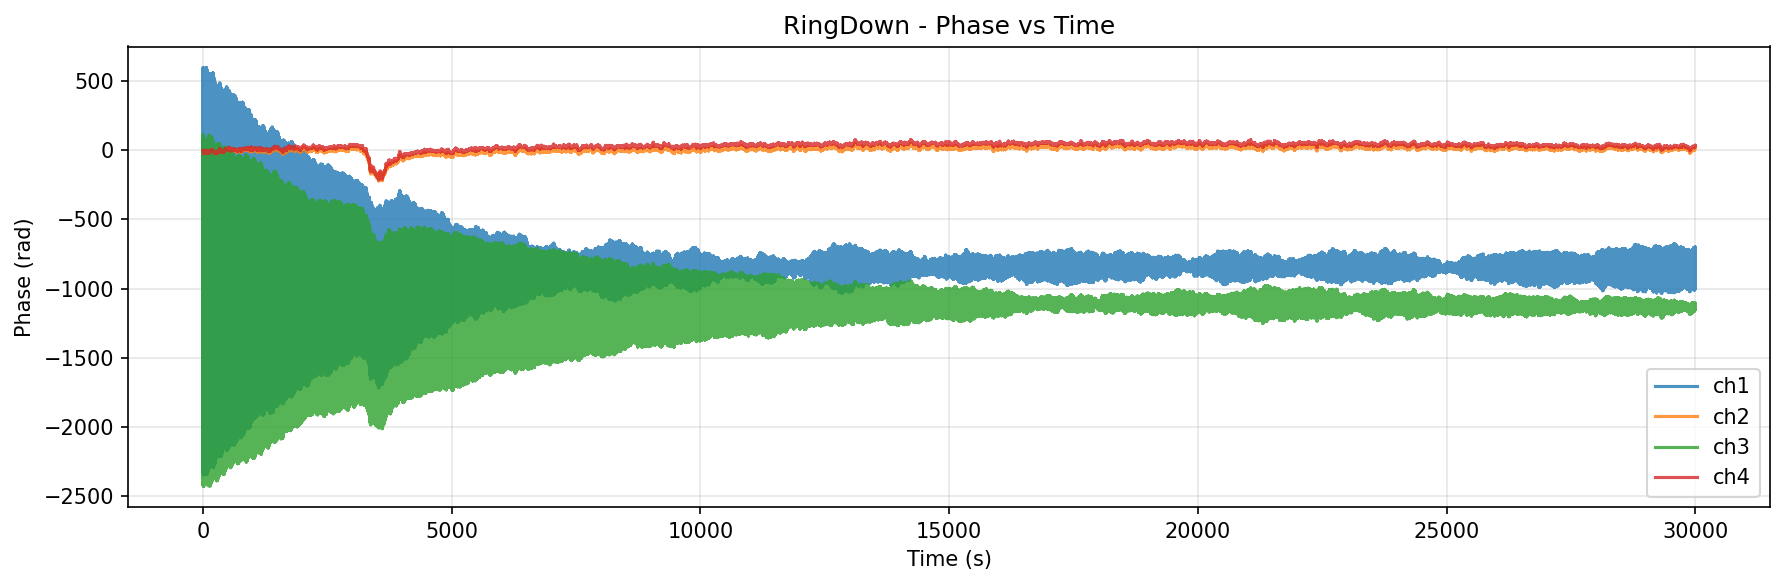

In [10]:
# Plot phase vs time (ring-down decay)
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
for i in range(1, pm.nchan + 1):
    col = f'{i}_phase'
    if col in pm.df.columns:
        ax.plot(pm.df['time'], pm.df[col], label=f'ch{i}', alpha=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Phase (rad)')
ax.set_title('RingDown - Phase vs Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
fig.savefig('ringdown_phase_vs_time.png')

/var/folders/z2/0sr40kf12437n7qv4v0qb7gm0000gn/T/ipykernel_7615/2847174215.py:1: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig('ringdown_phase_vs_time.png')


In [12]:
pm.df['tm1_cycles'] = pm.df['1_cycles'] - pm.df['2_cycles']
pm.df['tm2_cycles'] = pm.df['3_cycles'] - pm.df['4_cycles']

# pm.df['tm1_cycles'] = pm.df['1_phase'] - pm.df['2_phase']
# pm.df['tm2_cycles'] = pm.df['3_phase'] - pm.df['4_phase']

tm1_cycles: f_nls=7.666232 Hz, τ=6139.63 s (from Q), Q_nls=1.48e+05 | f_dft=7.666066 Hz, Q_dft=1.48e+05
tm2_cycles: f_nls=7.672962 Hz, τ=2518.49 s (from Q), Q_nls=6.07e+04 | f_dft=7.673008 Hz, Q_dft=1.67e-01


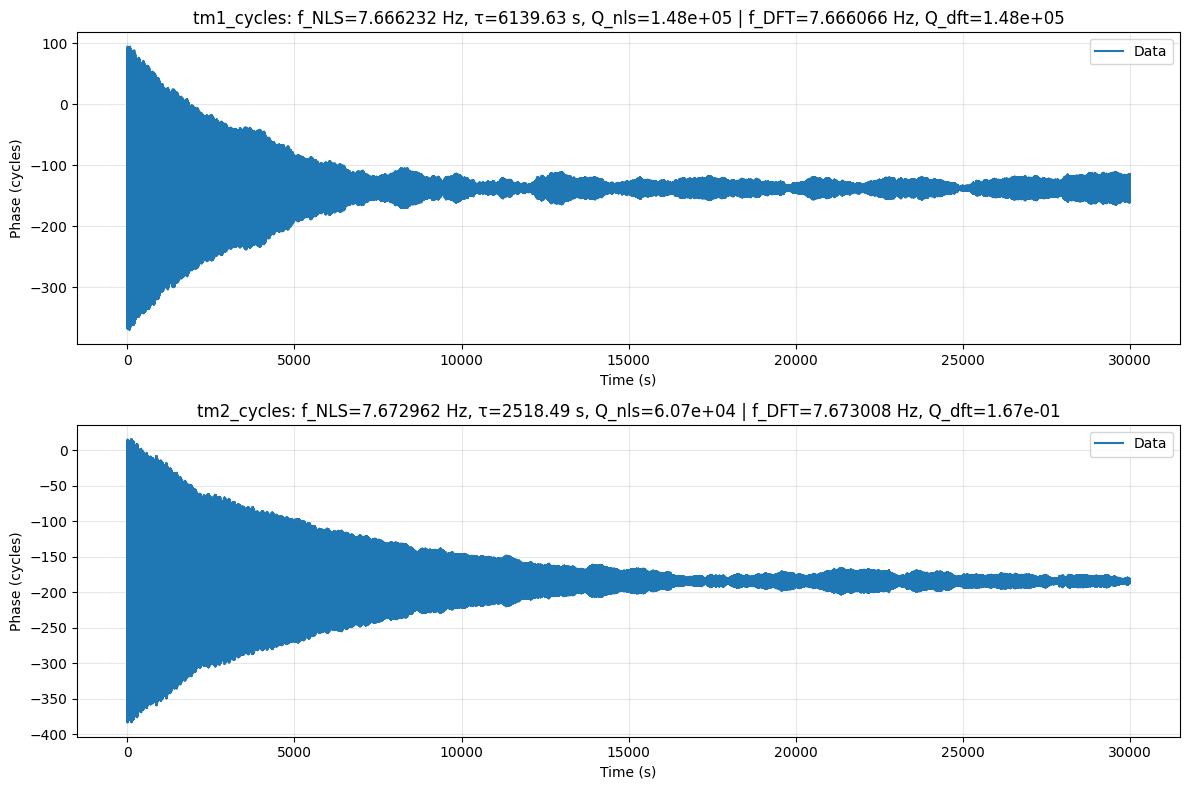

In [15]:
# Tau initial guess (s). Observed tau ~300-400 s; envelope estimate can fail on noisy data.
TAU_INIT = 4000

# Phase (cycles) data: f_min excludes low-freq bins so DFT finds the 7-8 Hz peak
dft_est = DFTFrequencyEstimator(window="rect", f_min=1.0)
analyzer = RingDownAnalyzer(dft_estimator=dft_est)
results = {}

# Parameters for noisy data: use DFT-derived initial params (None), relax tolerances,
# and allow enough iterations. Tight ftol/xtol cause convergence failures on noisy data.
NOISY_FIT_PARAMS = dict(
    initial_params=None,  # Let pipeline estimate (f0, A0, c0) from DFT per channel
    tau_init=TAU_INIT,
    max_nfev=1500,  # 5-param NLS needs many evals; 50 was too low
    ftol=1e-7,
    xtol=1e-7,
    gtol=1e-7,
    max_tau_multiplier=1,  # Use more data for frequency fit
)

for ch in ['tm1_cycles', 'tm2_cycles']:

    t = pm.df["time"].values - pm.df["time"].values[0]
    phase_cycles = pm.df[ch].values

    r = analyzer.analyze_array(t=t, data=phase_cycles, **NOISY_FIT_PARAMS)
    r["channel"] = ch
    results[ch] = r

    tau_from_Q = r["Q_nls"] / (np.pi * r["f_nls"]) if r.get("Q_nls") is not None else None
    tau_str = f"τ={tau_from_Q:.2f} s" if tau_from_Q is not None else "τ=N/A"
    q_nls_str = f"{r['Q_nls']:.2e}" if r.get("Q_nls") is not None else "N/A"
    q_dft_str = f"{r['Q_dft']:.2e}" if r.get("Q_dft") is not None else "N/A"
    print(f"{ch}: f_nls={r['f_nls']:.6f} Hz, {tau_str} (from Q), Q_nls={q_nls_str} | "
          f"f_dft={r['f_dft']:.6f} Hz, Q_dft={q_dft_str}")

if results:
    fig, axes = plt.subplots(len(results), 1, figsize=(12, 4 * len(results)), squeeze=False)
    for idx, (ch, r) in enumerate(results.items()):
        ax = axes[idx, 0]
        step = max(1, len(r["t"]) // 50000)
        ax.plot(r["t"][::step], r["data"][::step], label="Data")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Phase (cycles)")
        tau_from_Q = r["Q_nls"] / (np.pi * r["f_nls"]) if r.get("Q_nls") is not None else None
        tau_str = f"τ={tau_from_Q:.2f} s" if tau_from_Q is not None else "τ=N/A"
        q_nls_str = f"{r['Q_nls']:.2e}" if r.get("Q_nls") is not None else "N/A"
        q_dft_str = f"{r['Q_dft']:.2e}" if r.get("Q_dft") is not None else "N/A"
        ax.set_title(f"{ch}: f_NLS={r['f_nls']:.6f} Hz, {tau_str}, Q_nls={q_nls_str} | "
                     f"f_DFT={r['f_dft']:.6f} Hz, Q_dft={q_dft_str}")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()